In [1]:
import os
import cv2
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage.metrics import (
    peak_signal_noise_ratio,
    structural_similarity
)

In [2]:
low_path = "LOL-v2/Synthetic/Train/Low"
high_path = "LOL-v2/Synthetic/Train/Normal"

image_name = os.listdir(low_path)[0]

low_img = cv2.imread(
    os.path.join(low_path, image_name)
)

high_img = cv2.imread(
    os.path.join(high_path, image_name)
)

low_img = cv2.cvtColor(
    low_img,
    cv2.COLOR_BGR2RGB
)

high_img = cv2.cvtColor(
    high_img,
    cv2.COLOR_BGR2RGB
)

In [3]:
def apply_hist_eq(image):

    gray = cv2.cvtColor(
        image,
        cv2.COLOR_RGB2GRAY
    )

    return cv2.equalizeHist(gray)

In [4]:
def apply_clahe(image,
                clip=2.0,
                grid=(8,8)):

    gray = cv2.cvtColor(
        image,
        cv2.COLOR_RGB2GRAY
    )

    clahe = cv2.createCLAHE(
        clipLimit=clip,
        tileGridSize=grid
    )

    return clahe.apply(gray)

In [5]:
def apply_gamma(image,
                gamma=0.5):

    normalized = image / 255.0

    corrected = np.power(
        normalized,
        gamma
    )

    corrected = (
        corrected * 255
    ).astype(np.uint8)

    return corrected

In [6]:
hist_eq_img = apply_hist_eq(low_img)

clahe_img = apply_clahe(low_img)

gamma_img = apply_gamma(low_img)

In [7]:
# Peak Signal-to-Noise Ratio(PSNR)
# how close reconstructed image is to ground truth

In [8]:
# PSNR=10*log({MAX_I^2}/{MSE})
# human perception is nonlinear

In [9]:
gray_high = cv2.cvtColor(
    high_img,
    cv2.COLOR_RGB2GRAY
)

In [10]:
psnr_hist_eq = peak_signal_noise_ratio(
    gray_high,
    hist_eq_img
)

psnr_clahe = peak_signal_noise_ratio(
    gray_high,
    clahe_img
)

psnr_gamma = peak_signal_noise_ratio(
    high_img,
    gamma_img
)

In [11]:
print("PSNR Hist Eq:", psnr_hist_eq)
print("PSNR CLAHE:", psnr_clahe)
print("PSNR Gamma:", psnr_gamma)

PSNR Hist Eq: 22.5432865517133
PSNR CLAHE: 10.704421848633444
PSNR Gamma: 14.0512576032962


In [12]:
# PSNR < 20       : poor
# PSNR = 20 - 30  : acceptable
# PSNR > 30       : good


In [13]:
# Structural Similarity Index (SSIM)

In [14]:
ssim_hist_eq = structural_similarity(
    gray_high,
    hist_eq_img
)

ssim_clahe = structural_similarity(
    gray_high,
    clahe_img
)

ssim_gamma = structural_similarity(
    high_img,
    gamma_img,
    channel_axis=2
)

In [15]:
print("SSIM Hist Eq:", ssim_hist_eq)
print("SSIM CLAHE:", ssim_clahe)
print("SSIM Gamma:", ssim_gamma)

SSIM Hist Eq: 0.8635676438105689
SSIM CLAHE: 0.4259069830600894
SSIM Gamma: 0.7504158288875349


In [16]:
# Natural Image Quality Evaluator (NIQE)

In [17]:
import torch
import pyiqa

/Users/prabhavsinghal/Desktop/lol_dataset/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [18]:
niqe_metric = pyiqa.create_metric('niqe')

In [19]:
def to_tensor(image):

    image = image.astype(np.float32) / 255.0

    tensor = torch.tensor(image)

    tensor = tensor.permute(2,0,1)

    tensor = tensor.unsqueeze(0)

    return tensor

In [20]:
niqe_gamma = niqe_metric(
    to_tensor(gamma_img)
)

print(niqe_gamma)

tensor(4.4911, dtype=torch.float64)


In [21]:
start = time.time()

apply_hist_eq(low_img)

end = time.time()

hist_eq_time = end - start

In [22]:
start = time.time()

apply_clahe(low_img)

end = time.time()

clahe_time = end - start

In [23]:
start = time.time()

apply_gamma(low_img)

end = time.time()

gamma_time = end - start

In [24]:
print(hist_eq_time)
print(clahe_time)
print(gamma_time)

0.00029397010803222656
0.0003409385681152344
0.0012180805206298828


In [25]:
comparison = pd.DataFrame({

    "Method": [
        "Hist Eq",
        "CLAHE",
        "Gamma"
    ],

    "PSNR": [
        psnr_hist_eq,
        psnr_clahe,
        psnr_gamma
    ],

    "SSIM": [
        ssim_hist_eq,
        ssim_clahe,
        ssim_gamma
    ],

    "Inference Time": [
        hist_eq_time,
        clahe_time,
        gamma_time
    ]

})

comparison

,Method,PSNR,SSIM,Inference Time
0,Hist Eq,22.543287,0.863568,0.000294
1,CLAHE,10.704422,0.425907,0.000341
2,Gamma,14.051258,0.750416,0.001218


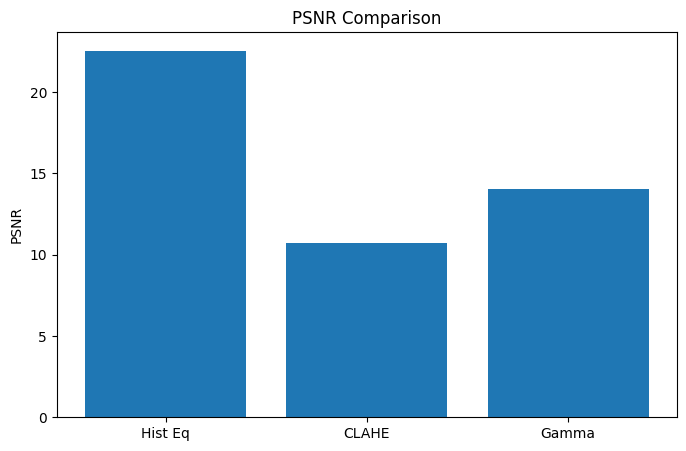

In [26]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Method"],
    comparison["PSNR"]
)

plt.title("PSNR Comparison")
plt.ylabel("PSNR")

plt.show()

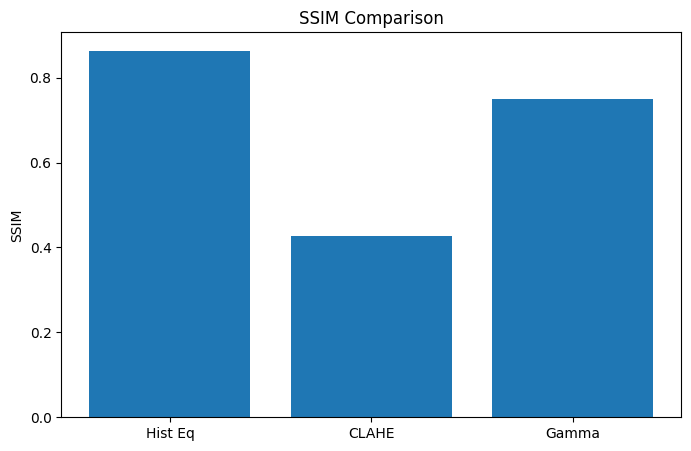

In [27]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Method"],
    comparison["SSIM"]
)

plt.title("SSIM Comparison")
plt.ylabel("SSIM")

plt.show()

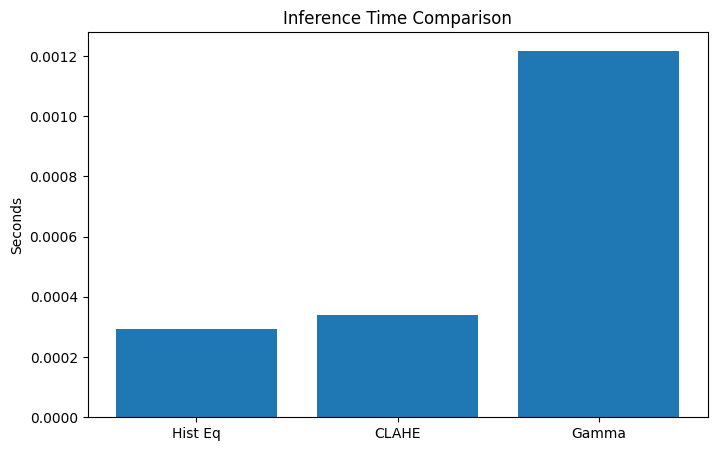

In [28]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Method"],
    comparison["Inference Time"]
)

plt.title("Inference Time Comparison")
plt.ylabel("Seconds")

plt.show()